# Outlier Dup Pair Statistics

이 노트북은 `trackB_070102`에서 export된 duplicate outlier 후보를 통계적으로 확인하기 위한 분석용 노트북이다.

핵심 확인 질문은 다음과 같다.

1. `dup_score > 0`으로 잡힌 후보들의 점수 분포는 어떤가?
2. `nearest_cos_sim`이 높은데 `dup_score`가 낮은 사례가 왜 생기는가?
3. `dup_source`가 pHash에 치우친 이유가 threshold 때문인지, 점수 산식 때문인지 확인한다.

`dup_score`는 duplicate 확률이 아니라, pHash distance 또는 ResNet-18 cosine similarity를 threshold 기준으로 0~1 사이에 재스케일한 ranking score이다.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 120)

PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name != "Quest02":
    PROJECT_DIR = Path("/home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02")

DETAIL_PATH = PROJECT_DIR / "outputs" / "trackB_070102" / "trackB_resnet18_scores_detail.csv"
OUTLIER_INDEX_PATH = PROJECT_DIR / "outputs" / "trackB_070102" / "outliers" / "outlier_index.csv"

print("PROJECT_DIR:", PROJECT_DIR)
print("DETAIL_PATH:", DETAIL_PATH)
print("OUTLIER_INDEX_PATH:", OUTLIER_INDEX_PATH)

PROJECT_DIR: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02
DETAIL_PATH: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/outputs/trackB_070102/trackB_resnet18_scores_detail.csv
OUTLIER_INDEX_PATH: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/outputs/trackB_070102/outliers/outlier_index.csv


## 1. 데이터 로드와 필수 컬럼 검증

여기서는 최신 산출물인 `trackB_070102` detail CSV를 기준으로 본다. 실제 outlier 이미지 export 파일 경로는 `outlier_index.csv`에서 가져와 `id` 기준으로 붙인다.

In [2]:
required_columns = {
    "id", "path", "dup_score", "nearest_cos_sim", "resnet18_dup_score",
    "phash_dup_score", "nearest_phash_dist", "dup_source",
    "effective_nearest_id", "label", "nearest_label", "label_conflict",
}

if not DETAIL_PATH.exists():
    raise FileNotFoundError(f"Missing detail CSV: {DETAIL_PATH}")

detail_df = pd.read_csv(DETAIL_PATH)
missing_columns = sorted(required_columns - set(detail_df.columns))
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

detail_df["id"] = detail_df["id"].astype(str)
detail_df["effective_nearest_id"] = detail_df["effective_nearest_id"].astype(str)

dup_export_df = pd.DataFrame(columns=["id", "export_file_path", "export_reason"])
if OUTLIER_INDEX_PATH.exists():
    outlier_index_df = pd.read_csv(OUTLIER_INDEX_PATH)
    dup_export_df = (
        outlier_index_df[outlier_index_df["type"].eq("dup")]
        .loc[:, ["id", "file_path", "reason"]]
        .rename(columns={"file_path": "export_file_path", "reason": "export_reason"})
        .assign(id=lambda d: d["id"].astype(str))
    )

analysis_df = detail_df.merge(dup_export_df, on="id", how="left")
dup_df = analysis_df[analysis_df["dup_score"] > 0].copy().reset_index(drop=True)
nondup_df = analysis_df[analysis_df["dup_score"] <= 0].copy().reset_index(drop=True)

print("detail_df shape:", detail_df.shape)
print("dup_df shape:", dup_df.shape)
print("nondup_df shape:", nondup_df.shape)
display(dup_df.head())

detail_df shape: (1366, 27)
dup_df shape: (155, 29)
nondup_df shape: (1211, 29)


,id,path,label,pred_label,pred_clean,pred_dusty,confidence,embedding_row,nearest_id,nearest_cos_sim,resnet18_dup_score,phash_dup_score,phash_nearest_id,nearest_phash_dist,dup_score,dup_source,effective_nearest_id,nearest_label,label_conflict,mean_cos,centroid_cos,density_rank,centroid_rank,ood_score_raw,ood_score,disagreement,mislabel_score,export_file_path,export_reason
0,train_00007,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,0,0,0.995062,4.937673e-03,0.990125,7,train_00301,0.903235,0.0,0.0625,train_00301,6.0,0.0625,phash,train_00301,0,False,0.813761,0.807538,0.685944,0.867496,0.241435,0.241435,4.937673e-03,3.708558e-03,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,dup_score=0.0625; nearest_cos_sim=0.9032; dup_...
1,train_00011,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,0,0,1.000000,8.266273e-09,1.000000,11,train_00798,0.994329,0.0,0.5625,train_00798,2.0,0.5625,phash,train_00798,0,False,0.866811,0.772366,0.996340,0.596633,0.163543,0.163543,8.266273e-09,6.914380e-09,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,dup_score=0.5625; nearest_cos_sim=0.9943; dup_...
2,train_00027,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,0,0,0.999631,3.686749e-04,0.999263,27,train_00502,0.990765,0.0,1.0000,train_00502,0.0,1.0000,phash,train_00502,0,False,0.831894,0.754331,0.857247,0.447291,0.306735,0.306735,3.686749e-04,2.554009e-04,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,dup_score=1.0000; nearest_cos_sim=0.9908; dup_...
3,train_00028,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,0,0,0.999408,5.919458e-04,0.998816,28,train_00580,0.942885,0.0,1.0000,train_00580,0.0,1.0000,phash,train_00580,0,False,0.779614,0.774212,0.336018,0.609078,0.554758,0.554758,5.919458e-04,2.632469e-04,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,dup_score=1.0000; nearest_cos_sim=0.9429; dup_...
4,train_00042,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,0,0,0.955525,4.447544e-02,0.911049,42,train_01118,0.995431,0.0,1.0000,train_01118,0.0,1.0000,phash,train_01118,1,True,0.786274,0.756108,0.402635,0.464861,0.572474,0.572474,4.447544e-02,1.732304e-02,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,dup_score=1.0000; nearest_cos_sim=0.9954; dup_...


## 2. 기본 dup 통계

CNN feature space에서 가까운 정도는 `nearest_cos_sim`, pHash 관점에서 가까운 정도는 `nearest_phash_dist`로 본다. CNN에서 배운 feature extractor 개념과 연결하면, `nearest_cos_sim`은 ResNet-18 embedding 사이의 cosine similarity이고, pHash는 학습 모델이 아닌 hand-crafted image fingerprint에 가깝다.

In [3]:
summary_df = pd.DataFrame([
    {"metric": "total_samples", "value": len(analysis_df)},
    {"metric": "dup_candidates", "value": len(dup_df)},
    {"metric": "dup_candidate_ratio", "value": len(dup_df) / len(analysis_df)},
    {"metric": "exported_dup_files", "value": int(dup_df["export_file_path"].notna().sum())},
    {"metric": "label_conflict_count", "value": int(dup_df["label_conflict"].fillna(False).sum())},
])
display(summary_df)

score_columns = [
    "dup_score", "nearest_cos_sim", "phash_dup_score",
    "resnet18_dup_score", "nearest_phash_dist",
]
display(dup_df[score_columns].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).T)

source_stats = (
    dup_df["dup_source"]
    .value_counts(dropna=False)
    .rename_axis("dup_source")
    .reset_index(name="count")
)
source_stats["ratio"] = source_stats["count"] / len(dup_df)
display(source_stats)

label_conflict_stats = (
    dup_df["label_conflict"]
    .fillna(False)
    .value_counts()
    .rename_axis("label_conflict")
    .reset_index(name="count")
)
label_conflict_stats["ratio"] = label_conflict_stats["count"] / len(dup_df)
display(label_conflict_stats)

,metric,value
0,total_samples,1366.00000
1,dup_candidates,155.00000
2,dup_candidate_ratio,0.11347
3,exported_dup_files,155.00000
4,label_conflict_count,20.00000


,count,mean,std,min,10%,25%,50%,75%,90%,95%,99%,max
dup_score,155.0,0.736290,0.336292,0.062500,0.250000,0.562500,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
nearest_cos_sim,155.0,0.977610,0.027723,0.811409,0.949564,0.970496,0.986528,0.995305,0.997868,0.998549,0.999297,0.999716
phash_dup_score,155.0,0.736290,0.336292,0.062500,0.250000,0.562500,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
resnet18_dup_score,155.0,0.042420,0.128310,0.000000,0.000000,0.000000,0.000000,0.000000,0.122602,0.311073,0.631069,0.834529
nearest_phash_dist,155.0,1.419355,1.960225,0.000000,0.000000,0.000000,0.000000,2.000000,4.000000,6.000000,6.000000,6.000000


,dup_source,count,ratio
0,phash,155,1.0


,label_conflict,count,ratio
0,False,135,0.870968
1,True,20,0.129032


## 3. 분포 시각화

plot 안의 text는 깨짐을 피하기 위해 영어로 둔다. `dup_score`는 확률이 아니라 threshold 기반 ranking score이므로, 분포의 높고 낮음은 duplicate 확률 그 자체가 아니라 현재 규칙이 얼마나 강하게 반응했는지로 해석한다.

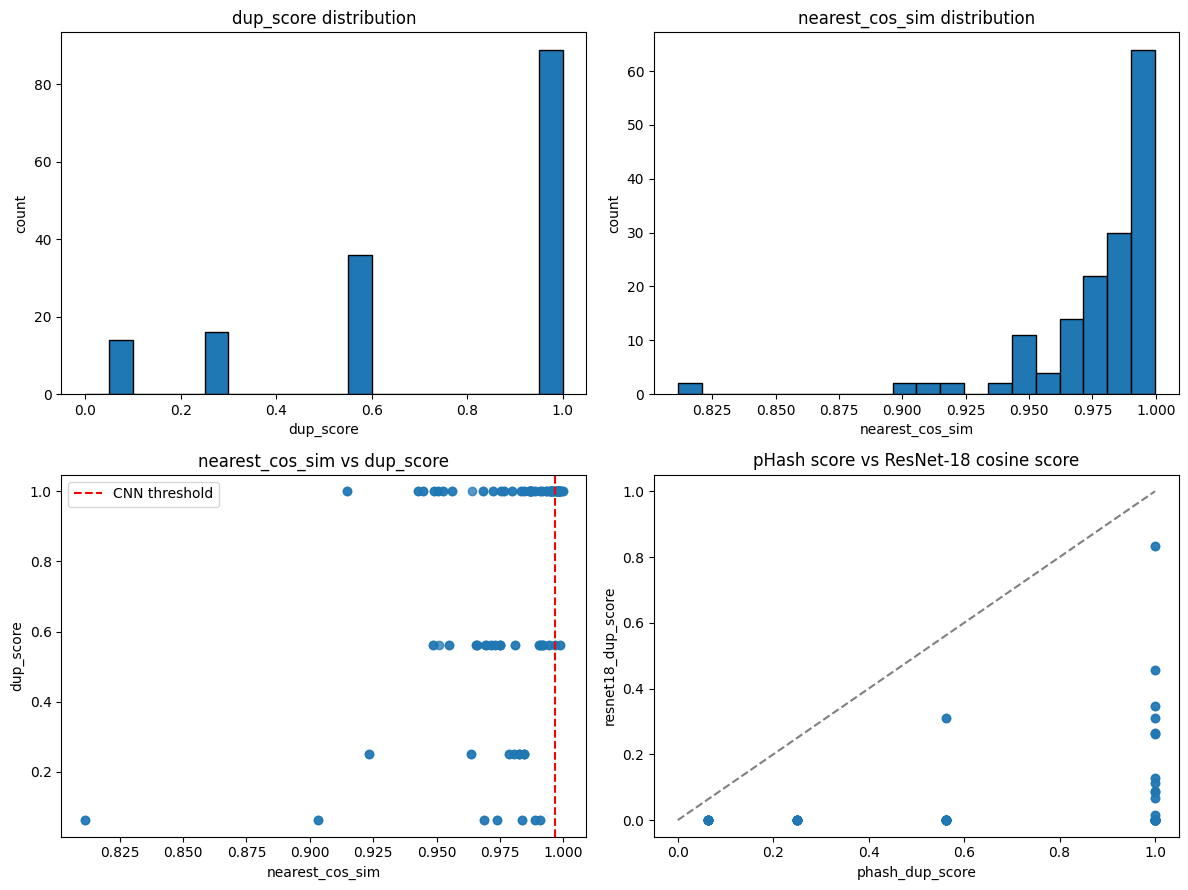

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0, 0].hist(dup_df["dup_score"], bins=np.linspace(0, 1, 21), edgecolor="black")
axes[0, 0].set_title("dup_score distribution")
axes[0, 0].set_xlabel("dup_score")
axes[0, 0].set_ylabel("count")

axes[0, 1].hist(dup_df["nearest_cos_sim"], bins=20, edgecolor="black")
axes[0, 1].set_title("nearest_cos_sim distribution")
axes[0, 1].set_xlabel("nearest_cos_sim")
axes[0, 1].set_ylabel("count")

axes[1, 0].scatter(dup_df["nearest_cos_sim"], dup_df["dup_score"], alpha=0.75)
axes[1, 0].axvline(0.9967193245887757, color="red", linestyle="--", label="CNN threshold")
axes[1, 0].set_title("nearest_cos_sim vs dup_score")
axes[1, 0].set_xlabel("nearest_cos_sim")
axes[1, 0].set_ylabel("dup_score")
axes[1, 0].legend()

axes[1, 1].scatter(dup_df["phash_dup_score"], dup_df["resnet18_dup_score"], alpha=0.75)
axes[1, 1].plot([0, 1], [0, 1], color="gray", linestyle="--")
axes[1, 1].set_title("pHash score vs ResNet-18 cosine score")
axes[1, 1].set_xlabel("phash_dup_score")
axes[1, 1].set_ylabel("resnet18_dup_score")

plt.tight_layout()
plt.show()

,nearest_cos_bin,count,dup_score_mean,dup_score_median,dup_score_min,dup_score_max,phash_dist_median,resnet18_nonzero
0,"(-0.001, 0.9]",2,0.062500,0.06250,0.0625,0.0625,6.0,0
1,"(0.9, 0.95]",14,0.696429,1.00000,0.0625,1.0000,0.0,0
2,"(0.95, 0.98]",43,0.659884,0.56250,0.0625,1.0000,2.0,0
3,"(0.98, 0.99]",32,0.621094,0.78125,0.0625,1.0000,1.0,0
4,"(0.99, 0.995]",24,0.739583,0.78125,0.0625,1.0000,1.0,0
5,"(0.995, 1.0]",40,0.956250,1.00000,0.5625,1.0000,0.0,28


/tmp/ipykernel_257475/1501440988.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(box_data, labels=box_labels, showmeans=True)


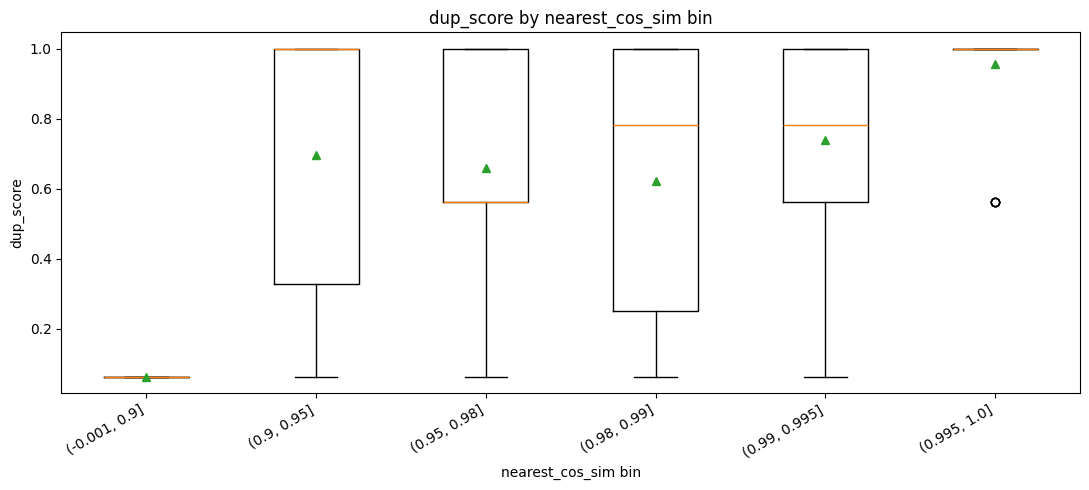

In [5]:
cos_bins = [0.0, 0.90, 0.95, 0.98, 0.99, 0.995, 1.0]
dup_df["nearest_cos_bin"] = pd.cut(dup_df["nearest_cos_sim"], bins=cos_bins, include_lowest=True)

cos_bin_stats = (
    dup_df.groupby("nearest_cos_bin", observed=False)
    .agg(
        count=("id", "size"),
        dup_score_mean=("dup_score", "mean"),
        dup_score_median=("dup_score", "median"),
        dup_score_min=("dup_score", "min"),
        dup_score_max=("dup_score", "max"),
        phash_dist_median=("nearest_phash_dist", "median"),
        resnet18_nonzero=("resnet18_dup_score", lambda s: int((s > 0).sum())),
    )
    .reset_index()
)
display(cos_bin_stats)

box_data = [
    group["dup_score"].dropna().to_numpy()
    for _, group in dup_df.groupby("nearest_cos_bin", observed=False)
]
box_labels = [str(x) for x in cos_bin_stats["nearest_cos_bin"]]

fig, ax = plt.subplots(figsize=(11, 5))
ax.boxplot(box_data, labels=box_labels, showmeans=True)
ax.set_title("dup_score by nearest_cos_sim bin")
ax.set_xlabel("nearest_cos_sim bin")
ax.set_ylabel("dup_score")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

,nearest_phash_dist,count,dup_score_mean,dup_score_min,dup_score_max,nearest_cos_median
0,0.0,89,1.0000,1.0000,1.0000,0.991543
1,2.0,36,0.5625,0.5625,0.5625,0.974955
2,4.0,16,0.2500,0.2500,0.2500,0.981537
3,6.0,14,0.0625,0.0625,0.0625,0.973739


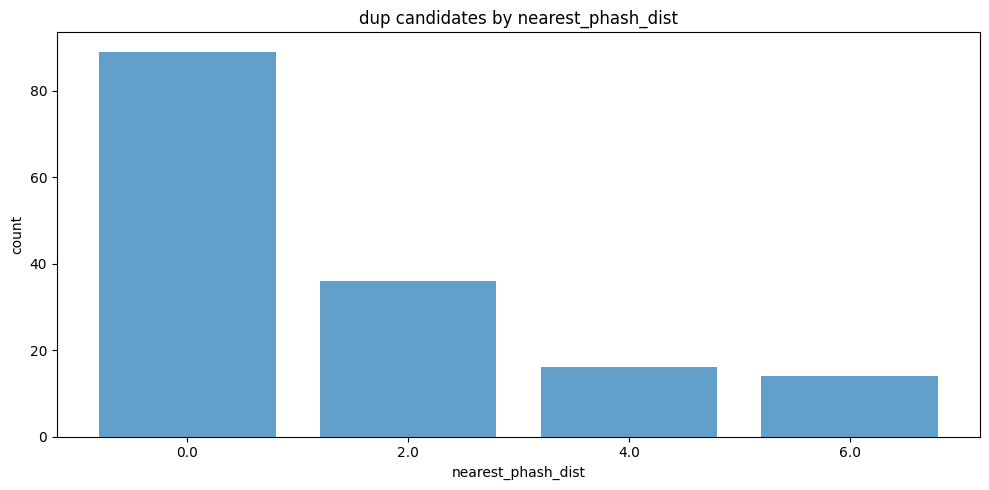

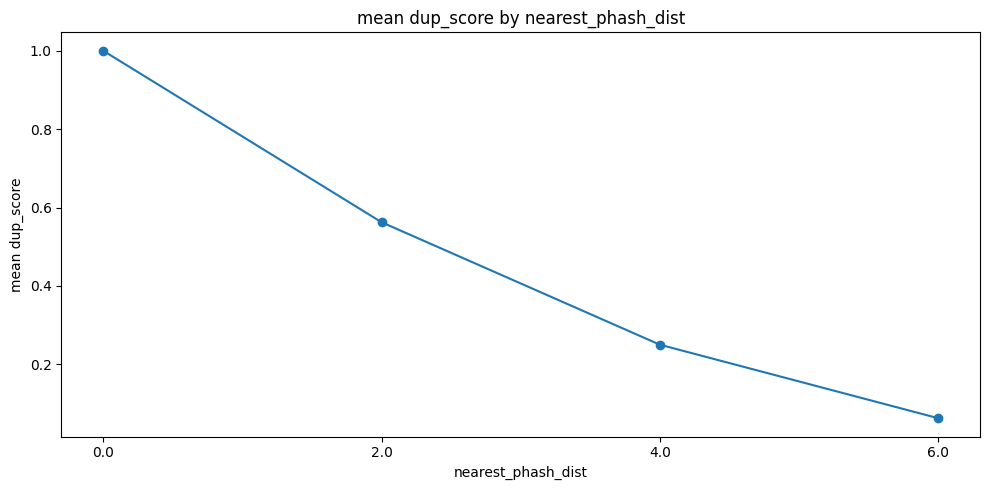

In [6]:
phash_dist_stats = (
    dup_df.groupby("nearest_phash_dist", dropna=False)
    .agg(
        count=("id", "size"),
        dup_score_mean=("dup_score", "mean"),
        dup_score_min=("dup_score", "min"),
        dup_score_max=("dup_score", "max"),
        nearest_cos_median=("nearest_cos_sim", "median"),
    )
    .reset_index()
    .sort_values("nearest_phash_dist")
)
display(phash_dist_stats)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(phash_dist_stats["nearest_phash_dist"].astype(str), phash_dist_stats["count"], alpha=0.7)
ax1.set_title("dup candidates by nearest_phash_dist")
ax1.set_xlabel("nearest_phash_dist")
ax1.set_ylabel("count")
plt.tight_layout()
plt.show()

fig, ax2 = plt.subplots(figsize=(10, 5))
ax2.plot(phash_dist_stats["nearest_phash_dist"].astype(str), phash_dist_stats["dup_score_mean"], marker="o")
ax2.set_title("mean dup_score by nearest_phash_dist")
ax2.set_xlabel("nearest_phash_dist")
ax2.set_ylabel("mean dup_score")
plt.tight_layout()
plt.show()

## 4. 의견 판단용 진단 표

ResNet-18 cosine score는 다음 산식으로 만들어졌다.

`resnet18_dup_score = clip((nearest_cos_sim - cnn_threshold) / (1 - cnn_threshold), 0, 1) ** 2`

따라서 `nearest_cos_sim`이 0.99처럼 높아 보여도 threshold가 약 0.9967이면 CNN duplicate score는 0이 된다. 이 점은 CNN에서 softmax confidence가 항상 정답 확률이 아닌 것처럼, 여기서도 cosine similarity와 최종 `dup_score`를 같은 의미로 보면 안 된다는 뜻이다.

In [7]:
CNN_DUP_THRESHOLD = 0.9967193245887757
CNN_DUP_POWER = 2.0

def resnet18_score_from_cos(cos_sim, threshold=CNN_DUP_THRESHOLD, power=CNN_DUP_POWER):
    denominator = max(1.0 - threshold, 1e-12)
    return np.clip((np.asarray(cos_sim, dtype=float) - threshold) / denominator, 0.0, 1.0) ** power

cos_probe = pd.DataFrame({
    "nearest_cos_sim": [0.9900, 0.9950, 0.9960, CNN_DUP_THRESHOLD, 0.9970, 0.9980, 0.9990, 1.0000]
})
cos_probe["resnet18_dup_score"] = resnet18_score_from_cos(cos_probe["nearest_cos_sim"])
display(cos_probe)

high_cos_low_dup = (
    dup_df[(dup_df["nearest_cos_sim"] >= 0.99) & (dup_df["dup_score"] <= 0.6)]
    .sort_values(["nearest_cos_sim", "dup_score"], ascending=[False, True])
    .loc[:, [
        "id", "effective_nearest_id", "label", "nearest_label", "label_conflict",
        "dup_score", "nearest_cos_sim", "resnet18_dup_score", "phash_dup_score",
        "nearest_phash_dist", "dup_source", "export_file_path",
    ]]
)
print("nearest_cos_sim >= 0.99 and dup_score <= 0.6:", len(high_cos_low_dup))
display(high_cos_low_dup)

,nearest_cos_sim,resnet18_dup_score
0,0.990000,0.000000
1,0.995000,0.000000
2,0.996000,0.000000
3,0.996719,0.000000
4,0.997000,0.007320
5,0.998000,0.152388
6,0.999000,0.483282
7,1.000000,1.000000


nearest_cos_sim >= 0.99 and dup_score <= 0.6: 16


,id,effective_nearest_id,label,nearest_label,label_conflict,dup_score,nearest_cos_sim,resnet18_dup_score,phash_dup_score,nearest_phash_dist,dup_source,export_file_path
120,train_01098,train_01190,1,1,False,0.5625,0.998552,0.312081,0.5625,2.0,phash,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...
135,train_01190,train_01098,1,1,False,0.5625,0.998552,0.312081,0.5625,2.0,phash,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...
19,train_00159,train_00261,0,1,True,0.5625,0.996777,0.000309,0.5625,2.0,phash,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...
28,train_00261,train_00159,1,0,True,0.5625,0.996777,0.000309,0.5625,2.0,phash,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...
1,train_00011,train_00798,0,0,False,0.5625,0.994329,0.000000,0.5625,2.0,phash,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...
91,train_00798,train_00011,0,0,False,0.5625,0.994329,0.000000,0.5625,2.0,phash,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...
16,train_00135,train_00636,1,1,False,0.5625,0.992102,0.000000,0.5625,2.0,phash,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...
71,train_00636,train_00135,1,1,False,0.5625,0.992102,0.000000,0.5625,2.0,phash,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...
11,train_00115,train_01234,1,1,False,0.5625,0.991526,0.000000,0.5625,2.0,phash,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...
143,train_01234,train_00115,1,1,False,0.5625,0.991526,0.000000,0.5625,2.0,phash,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...


In [8]:
source_membership = pd.DataFrame({
    "group": [
        "phash_dup_score > 0",
        "resnet18_dup_score > 0",
        "both > 0",
        "phash only",
        "resnet18 only",
        "dup_source == phash",
        "dup_source == resnet18_cosine",
    ],
    "count": [
        int((analysis_df["phash_dup_score"] > 0).sum()),
        int((analysis_df["resnet18_dup_score"] > 0).sum()),
        int(((analysis_df["phash_dup_score"] > 0) & (analysis_df["resnet18_dup_score"] > 0)).sum()),
        int(((analysis_df["phash_dup_score"] > 0) & (analysis_df["resnet18_dup_score"] <= 0)).sum()),
        int(((analysis_df["phash_dup_score"] <= 0) & (analysis_df["resnet18_dup_score"] > 0)).sum()),
        int(analysis_df["dup_source"].eq("phash").sum()),
        int(analysis_df["dup_source"].eq("resnet18_cosine").sum()),
    ],
})
source_membership["ratio_total"] = source_membership["count"] / len(analysis_df)
display(source_membership)

resnet18_nonzero_examples = (
    analysis_df[analysis_df["resnet18_dup_score"] > 0]
    .sort_values("resnet18_dup_score", ascending=False)
    .loc[:, [
        "id", "effective_nearest_id", "dup_score", "nearest_cos_sim",
        "resnet18_dup_score", "phash_dup_score", "nearest_phash_dist", "dup_source",
        "label", "nearest_label", "label_conflict",
    ]]
)
print("resnet18_dup_score > 0 examples:", len(resnet18_nonzero_examples))
display(resnet18_nonzero_examples.head(50))

,group,count,ratio_total
0,phash_dup_score > 0,155,0.113470
1,resnet18_dup_score > 0,28,0.020498
2,both > 0,28,0.020498
3,phash only,127,0.092972
4,resnet18 only,0,0.000000
5,dup_source == phash,155,0.113470
6,dup_source == resnet18_cosine,0,0.000000


resnet18_dup_score > 0 examples: 28


,id,effective_nearest_id,dup_score,nearest_cos_sim,resnet18_dup_score,phash_dup_score,nearest_phash_dist,dup_source,label,nearest_label,label_conflict
60,train_00060,train_00288,1.0000,0.999716,0.834529,1.0000,0.0,phash,0,0,False
288,train_00288,train_00060,1.0000,0.999716,0.834529,1.0000,0.0,phash,0,0,False
731,train_00731,train_01004,1.0000,0.998939,0.457751,1.0000,0.0,phash,0,0,False
1004,train_01004,train_00731,1.0000,0.998939,0.457751,1.0000,0.0,phash,0,0,False
657,train_00657,train_00477,1.0000,0.998648,0.345640,1.0000,0.0,phash,1,1,False
477,train_00477,train_00657,1.0000,0.998648,0.345640,1.0000,0.0,phash,1,1,False
1190,train_01190,train_01098,0.5625,0.998552,0.312081,0.5625,2.0,phash,1,1,False
1098,train_01098,train_01190,0.5625,0.998552,0.312081,0.5625,2.0,phash,1,1,False
881,train_00881,train_01191,1.0000,0.998548,0.310641,1.0000,0.0,phash,1,1,False
1191,train_01191,train_00881,1.0000,0.998548,0.310641,1.0000,0.0,phash,1,1,False


## 5. threshold가 너무 높은지 보기 위한 주변 샘플

현재 dup 후보에서 FP가 거의 없어 보인다면, 다음으로 봐야 할 것은 `dup_score == 0` 중에서도 CNN cosine이 높거나 pHash distance가 threshold 근처인 샘플이다. 즉 threshold를 낮췄을 때 새로 들어올 후보들이 실제 duplicate인지 확인해야 한다.

In [9]:
near_miss_by_cos = (
    nondup_df.sort_values("nearest_cos_sim", ascending=False)
    .loc[:, [
        "id", "nearest_id", "effective_nearest_id", "label", "nearest_label",
        "dup_score", "nearest_cos_sim", "resnet18_dup_score", "phash_dup_score",
        "nearest_phash_dist", "dup_source", "path",
    ]]
    .head(30)
)
print("Top non-dup rows by nearest_cos_sim")
display(near_miss_by_cos)

near_miss_by_phash = (
    nondup_df.sort_values("nearest_phash_dist", ascending=True)
    .loc[:, [
        "id", "nearest_id", "effective_nearest_id", "label", "nearest_label",
        "dup_score", "nearest_cos_sim", "resnet18_dup_score", "phash_dup_score",
        "nearest_phash_dist", "dup_source", "path",
    ]]
    .head(30)
)
print("Top non-dup rows by nearest_phash_dist")
display(near_miss_by_phash)

Top non-dup rows by nearest_cos_sim


,id,nearest_id,effective_nearest_id,label,nearest_label,dup_score,nearest_cos_sim,resnet18_dup_score,phash_dup_score,nearest_phash_dist,dup_source,path
690,train_00779,train_00162,train_00162,0,0,0.0,0.992599,0.0,0.0,12.0,none,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...
142,train_00162,train_00779,train_00779,0,0,0.0,0.992599,0.0,0.0,14.0,none,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...
72,train_00080,train_01052,train_01052,1,1,0.0,0.988372,0.0,0.0,10.0,none,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...
939,train_01052,train_00080,train_00080,1,1,0.0,0.988372,0.0,0.0,10.0,none,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...
1206,train_01361,train_00317,train_00317,1,1,0.0,0.988186,0.0,0.0,18.0,none,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...
281,train_00317,train_01361,train_01361,1,1,0.0,0.988186,0.0,0.0,16.0,none,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...
965,train_01084,train_00444,train_00444,1,1,0.0,0.985996,0.0,0.0,16.0,none,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...
395,train_00444,train_01084,train_01084,1,1,0.0,0.985996,0.0,0.0,16.0,none,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...
689,train_00778,train_00539,train_00539,0,0,0.0,0.984099,0.0,0.0,14.0,none,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...
477,train_00539,train_00778,train_00778,0,0,0.0,0.984099,0.0,0.0,14.0,none,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...


Top non-dup rows by nearest_phash_dist


,id,nearest_id,effective_nearest_id,label,nearest_label,dup_score,nearest_cos_sim,resnet18_dup_score,phash_dup_score,nearest_phash_dist,dup_source,path
77,train_00086,train_01205,train_01205,1,1,0.0,0.966474,0.0,0.0,8.0,none,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...
1066,train_01205,train_00086,train_00086,1,1,0.0,0.966474,0.0,0.0,8.0,none,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...
541,train_00610,train_01077,train_01077,1,1,0.0,0.971083,0.0,0.0,8.0,none,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...
960,train_01077,train_00610,train_00610,1,1,0.0,0.971083,0.0,0.0,8.0,none,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...
977,train_01097,train_00470,train_00470,1,1,0.0,0.794319,0.0,0.0,8.0,none,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...
405,train_00455,train_00129,train_00129,0,0,0.0,0.809590,0.0,0.0,8.0,none,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...
224,train_00250,train_00950,train_00950,0,0,0.0,0.924067,0.0,0.0,10.0,none,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...
72,train_00080,train_01052,train_01052,1,1,0.0,0.988372,0.0,0.0,10.0,none,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...
630,train_00715,train_00326,train_00326,0,0,0.0,0.943634,0.0,0.0,10.0,none,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...
41,train_00046,train_00391,train_00391,1,1,0.0,0.960729,0.0,0.0,10.0,none,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...


## 6. OOD / mislabel 점수 구간별 분포

`ood_score`와 `mislabel_score`는 현재 모든 샘플이 0보다 큰 값을 가진다. 따라서 `score > 0` 전체를 하나씩 보는 방식은 의미가 약하고, 0.05 단위 bin으로 나누어 분포와 대표 샘플을 보는 편이 낫다.

- `ood_score`: feature space에서 주변 밀도가 낮거나 class centroid에서 멀수록 높아진다.
- `mislabel_score`: 현재 라벨과 모델 예측이 충돌하고, 모델 confidence가 높으며, OOD 가능성은 상대적으로 낮을 때 높아진다.

CNN에서 validation loss/accuracy를 함께 보듯이, 여기서도 하나의 점수만 단독으로 판단하지 않고 `confidence`, `disagreement`, `mean_cos`, `centroid_cos`를 같이 본다.

,count,mean,std,min,5%,10%,25%,50%,75%,90%,95%,99%,max
ood_score,1366.0,0.499634,0.211868,3.748170e-02,1.772328e-01,0.234041,0.336493,0.480234,0.638543,0.814422,0.884370,0.976142,0.997218
mislabel_score,1366.0,0.020653,0.083063,1.486201e-11,7.168895e-07,0.000006,0.000082,0.000759,0.004966,0.026554,0.062353,0.490150,0.919247


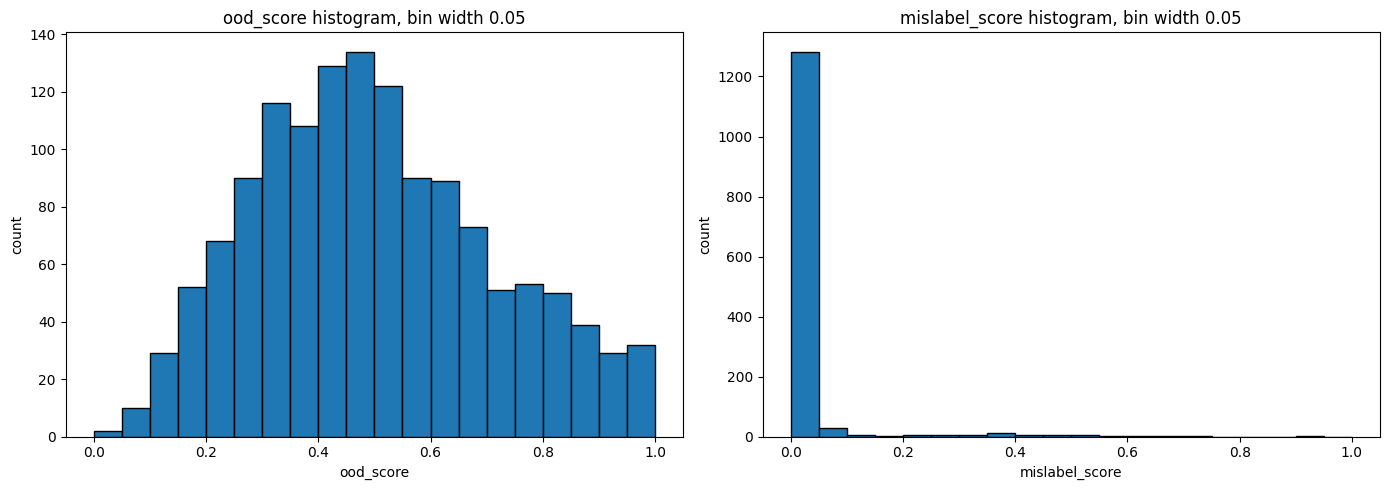

In [10]:
ood_mislabel_required_columns = {
    "id", "path", "label", "pred_label", "pred_clean", "pred_dusty",
    "confidence", "ood_score", "ood_score_raw", "mean_cos", "centroid_cos",
    "density_rank", "centroid_rank", "mislabel_score", "disagreement",
}
missing_ood_mislabel_columns = sorted(ood_mislabel_required_columns - set(analysis_df.columns))
if missing_ood_mislabel_columns:
    raise ValueError(f"Missing OOD/mislabel columns: {missing_ood_mislabel_columns}")

score_bin_edges = np.round(np.linspace(0.0, 1.0, 21), 2)
score_bin_labels = [f"{score_bin_edges[i]:.2f}-{score_bin_edges[i + 1]:.2f}" for i in range(len(score_bin_edges) - 1)]

analysis_df["ood_score_bin"] = pd.cut(
    analysis_df["ood_score"],
    bins=score_bin_edges,
    labels=score_bin_labels,
    include_lowest=True,
)
analysis_df["mislabel_score_bin"] = pd.cut(
    analysis_df["mislabel_score"],
    bins=score_bin_edges,
    labels=score_bin_labels,
    include_lowest=True,
)

score_distribution_summary = analysis_df[["ood_score", "mislabel_score"]].describe(
    percentiles=[0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
).T
display(score_distribution_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
axes[0].hist(analysis_df["ood_score"], bins=score_bin_edges, edgecolor="black")
axes[0].set_title("ood_score histogram, bin width 0.05")
axes[0].set_xlabel("ood_score")
axes[0].set_ylabel("count")

axes[1].hist(analysis_df["mislabel_score"], bins=score_bin_edges, edgecolor="black")
axes[1].set_title("mislabel_score histogram, bin width 0.05")
axes[1].set_xlabel("mislabel_score")
axes[1].set_ylabel("count")

plt.tight_layout()
plt.show()

OOD score bin stats


,ood_score_bin,count,score_min,score_max,score_mean,confidence_median,disagreement_median,dup_positive,ratio
0,0.00-0.05,2,0.037482,0.039678,0.038580,0.999844,0.000078,1,0.001464
1,0.05-0.10,10,0.053587,0.097511,0.078009,0.999012,0.000499,3,0.007321
2,0.10-0.15,29,0.101903,0.148902,0.129495,0.999904,0.000048,7,0.021230
3,0.15-0.20,52,0.150366,0.199268,0.175932,0.999770,0.000115,13,0.038067
4,0.20-0.25,68,0.200146,0.248170,0.225713,0.999778,0.000111,12,0.049780
5,0.25-0.30,90,0.250805,0.299854,0.276973,0.999407,0.000296,9,0.065886
6,0.30-0.35,116,0.300439,0.349048,0.324731,0.998754,0.000645,16,0.084919
7,0.35-0.40,108,0.350073,0.399268,0.377607,0.998501,0.000750,14,0.079063
8,0.40-0.45,129,0.400146,0.449341,0.424853,0.998830,0.000585,15,0.094436
9,0.45-0.50,134,0.450512,0.499561,0.476555,0.996357,0.001979,18,0.098097


Mislabel score bin stats


,mislabel_score_bin,count,score_min,score_max,score_mean,confidence_median,disagreement_median,dup_positive,ratio
0,0.00-0.05,1283,1.486201e-11,0.049045,0.004055,0.997136,0.001432,148,0.939239
1,0.05-0.10,30,5.029878e-02,0.099763,0.064565,0.493697,0.267691,3,0.021962
2,0.10-0.15,4,1.156838e-01,0.139627,0.129196,0.592703,0.796352,0,0.002928
3,0.15-0.20,2,1.709338e-01,0.197912,0.184423,0.695490,0.847745,0,0.001464
4,0.20-0.25,4,2.255800e-01,0.240611,0.234440,0.679305,0.839652,0,0.002928
5,0.25-0.30,4,2.536115e-01,0.293338,0.278590,0.796522,0.898261,0,0.002928
6,0.30-0.35,5,3.036121e-01,0.348471,0.327248,0.854949,0.927474,1,0.003660
7,0.35-0.40,11,3.518293e-01,0.394181,0.365773,0.896710,0.948355,0,0.008053
8,0.40-0.45,5,4.062560e-01,0.445740,0.428225,0.922537,0.961269,0,0.003660
9,0.45-0.50,5,4.610643e-01,0.496471,0.478667,0.969430,0.984715,1,0.003660


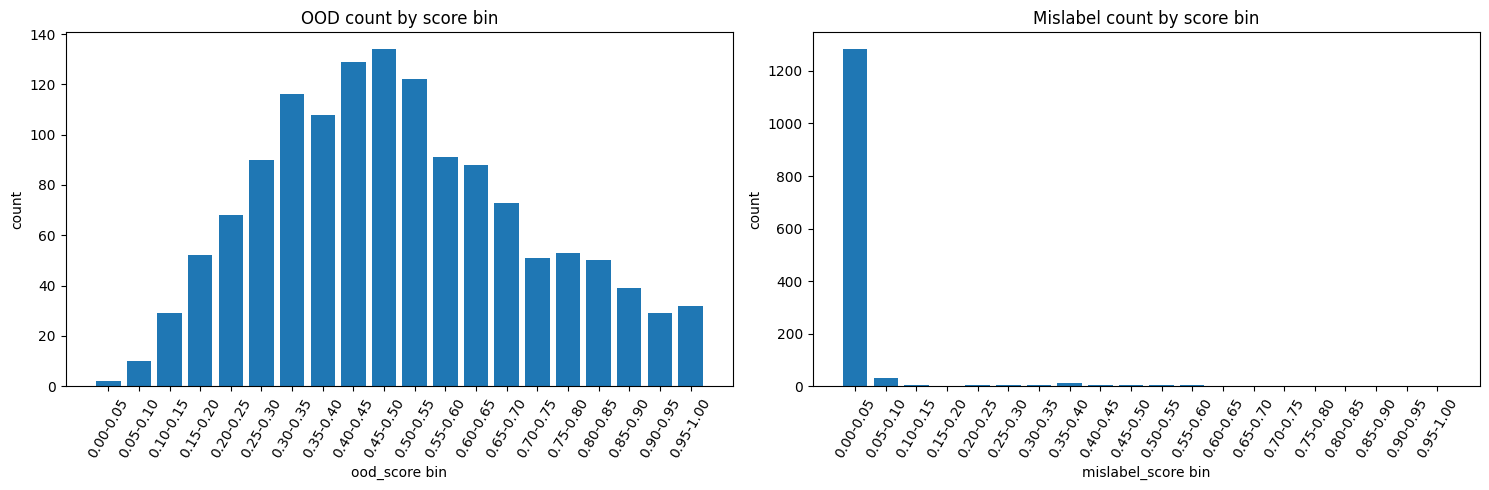

In [11]:
def make_score_bin_stats(df, score_col, bin_col):
    stats = (
        df.groupby(bin_col, observed=False)
        .agg(
            count=("id", "size"),
            score_min=(score_col, "min"),
            score_max=(score_col, "max"),
            score_mean=(score_col, "mean"),
            confidence_median=("confidence", "median"),
            disagreement_median=("disagreement", "median"),
            dup_positive=("dup_score", lambda s: int((s > 0).sum())),
        )
        .reset_index()
    )
    stats["ratio"] = stats["count"] / len(df)
    return stats

ood_bin_stats = make_score_bin_stats(analysis_df, "ood_score", "ood_score_bin")
mislabel_bin_stats = make_score_bin_stats(analysis_df, "mislabel_score", "mislabel_score_bin")

print("OOD score bin stats")
display(ood_bin_stats)

print("Mislabel score bin stats")
display(mislabel_bin_stats)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].bar(ood_bin_stats["ood_score_bin"].astype(str), ood_bin_stats["count"])
axes[0].set_title("OOD count by score bin")
axes[0].set_xlabel("ood_score bin")
axes[0].set_ylabel("count")
axes[0].tick_params(axis="x", rotation=60)

axes[1].bar(mislabel_bin_stats["mislabel_score_bin"].astype(str), mislabel_bin_stats["count"])
axes[1].set_title("Mislabel count by score bin")
axes[1].set_xlabel("mislabel_score bin")
axes[1].set_ylabel("count")
axes[1].tick_params(axis="x", rotation=60)

plt.tight_layout()
plt.show()

## 7. 점수 구간별 대표 샘플

아래 표는 각 0.05 점수 구간에서 점수가 높은 샘플을 최대 5개씩 뽑는다. 이렇게 보면 전체 1366개를 한 번에 보지 않고, 높은 구간부터 낮은 구간으로 검수 범위를 조절할 수 있다.

In [12]:
export_lookup_columns = ["id", "type", "file_path", "reason"]
score_export_df = pd.DataFrame(columns=export_lookup_columns)
if OUTLIER_INDEX_PATH.exists():
    score_export_df = pd.read_csv(OUTLIER_INDEX_PATH)
    score_export_df["id"] = score_export_df["id"].astype(str)
    score_export_df = score_export_df[score_export_df["type"].isin(["ood", "mislabel"])]

def attach_export_path(df, kind):
    export_part = (
        score_export_df[score_export_df["type"].eq(kind)]
        .loc[:, ["id", "file_path", "reason"]]
        .rename(columns={"file_path": f"{kind}_export_file_path", "reason": f"{kind}_export_reason"})
    )
    return df.merge(export_part, on="id", how="left")

def make_binned_review_samples(df, score_col, bin_col, n_per_bin=5):
    review_columns = [
        "id", bin_col, score_col, "label", "pred_label", "pred_clean", "pred_dusty",
        "confidence", "disagreement", "ood_score", "mislabel_score",
        "mean_cos", "centroid_cos", "density_rank", "centroid_rank",
        "dup_score", "path",
    ]
    rows = []
    for _, group in df.sort_values(score_col, ascending=False).groupby(bin_col, observed=False):
        rows.append(group.sort_values(score_col, ascending=False).head(n_per_bin).loc[:, review_columns])
    if not rows:
        return pd.DataFrame(columns=review_columns)
    return pd.concat(rows, ignore_index=True)

ood_binned_samples = make_binned_review_samples(analysis_df, "ood_score", "ood_score_bin", n_per_bin=5)
ood_binned_samples = attach_export_path(ood_binned_samples, "ood")

mislabel_binned_samples = make_binned_review_samples(analysis_df, "mislabel_score", "mislabel_score_bin", n_per_bin=5)
mislabel_binned_samples = attach_export_path(mislabel_binned_samples, "mislabel")

print("OOD binned review samples")
display(ood_binned_samples)

print("Mislabel binned review samples")
display(mislabel_binned_samples)

OOD binned review samples


,id,ood_score_bin,ood_score,label,pred_label,pred_clean,pred_dusty,confidence,disagreement,ood_score,mislabel_score,mean_cos,centroid_cos,density_rank,centroid_rank,dup_score,path,ood_export_file_path,ood_export_reason
0,train_00283,0.00-0.05,0.039678,0,0,0.999855,1.449161e-04,0.999710,1.449161e-04,0.039678,1.391258e-04,0.850440,0.825759,0.967057,0.950220,0.2500,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,ood_score=0.0397; mean_cos=0.8504; centroid_co...
1,train_00534,0.00-0.05,0.037482,0,0,0.999989,1.132711e-05,0.999977,1.132711e-05,0.037482,1.090231e-05,0.861559,0.818259,0.991215,0.919473,0.0000,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,ood_score=0.0375; mean_cos=0.8616; centroid_co...
2,train_00725,0.05-0.10,0.097511,0,0,0.999988,1.227829e-05,0.999975,1.227829e-05,0.097511,1.108075e-05,0.832793,0.830162,0.863836,0.960469,0.0000,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,ood_score=0.0975; mean_cos=0.8328; centroid_co...
3,train_00553,0.05-0.10,0.093119,1,1,0.018252,9.817478e-01,0.963496,1.825219e-02,0.093119,1.594833e-02,0.839143,0.817126,0.903367,0.912152,0.0000,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,ood_score=0.0931; mean_cos=0.8391; centroid_co...
4,train_00897,0.05-0.10,0.091362,0,0,0.999596,4.037230e-04,0.999193,4.037230e-04,0.091362,3.665420e-04,0.836015,0.823446,0.887262,0.940703,0.0000,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,ood_score=0.0914; mean_cos=0.8360; centroid_co...
5,train_01178,0.05-0.10,0.087262,0,0,0.999766,2.338797e-04,0.999532,2.338797e-04,0.087262,2.133710e-04,0.836609,0.824977,0.890190,0.946559,0.0000,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,ood_score=0.0873; mean_cos=0.8366; centroid_co...
6,train_00712,0.05-0.10,0.084041,0,0,0.999302,6.980581e-04,0.998604,6.980581e-04,0.084041,6.384999e-04,0.832375,0.852484,0.862372,0.996340,1.0000,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,ood_score=0.0840; mean_cos=0.8324; centroid_co...
7,train_00229,0.10-0.15,0.148902,0,0,0.999888,1.115202e-04,0.999777,1.115202e-04,0.148902,9.489344e-05,0.862214,0.776860,0.993411,0.637628,1.0000,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,ood_score=0.1489; mean_cos=0.8622; centroid_co...
8,train_01246,0.10-0.15,0.145534,0,0,0.999991,9.009844e-06,0.999982,9.009844e-06,0.145534,7.698463e-06,0.833323,0.801994,0.866764,0.836018,0.0000,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,ood_score=0.1455; mean_cos=0.8333; centroid_co...
9,train_00133,0.10-0.15,0.145388,0,0,0.999173,8.267546e-04,0.998347,8.267546e-04,0.145388,7.053861e-04,0.822191,0.838456,0.770864,0.980234,0.5625,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,ood_score=0.1454; mean_cos=0.8222; centroid_co...


Mislabel binned review samples


,id,mislabel_score_bin,mislabel_score,label,pred_label,pred_clean,pred_dusty,confidence,disagreement,ood_score,mislabel_score,mean_cos,centroid_cos,density_rank,centroid_rank,dup_score,path,mislabel_export_file_path,mislabel_export_reason
0,train_00379,0.00-0.05,0.049045,0,0,0.811932,0.188068,0.623863,0.188068,0.581991,0.049045,0.743104,0.810882,0.107613,0.883602,0.0000,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,mislabel_score=0.0490; label=0; pred_label=0; ...
1,train_00202,0.00-0.05,0.048776,0,0,0.778424,0.221576,0.556848,0.221576,0.604685,0.048776,0.751727,0.791926,0.147877,0.766471,0.0000,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,mislabel_score=0.0488; label=0; pred_label=0; ...
2,train_00646,0.00-0.05,0.048610,0,0,0.892338,0.107662,0.784676,0.107662,0.424597,0.048610,0.775885,0.842819,0.300146,0.988287,0.2500,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,mislabel_score=0.0486; label=0; pred_label=0; ...
3,train_00772,0.00-0.05,0.048304,0,0,0.709908,0.290092,0.419815,0.290092,0.603367,0.048304,0.732486,0.812858,0.068082,0.889458,0.0000,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,mislabel_score=0.0483; label=0; pred_label=0; ...
4,train_00281,0.00-0.05,0.048110,0,0,0.880774,0.119226,0.761548,0.119226,0.470132,0.048110,0.764045,0.848971,0.220351,0.994143,0.0000,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,mislabel_score=0.0481; label=0; pred_label=0; ...
5,train_00719,0.05-0.10,0.099763,1,0,0.682092,0.317908,0.364183,0.682092,0.598389,0.099763,0.737001,0.811704,0.078331,0.886530,0.0000,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,mislabel_score=0.0998; label=1; pred_label=0; ...
6,train_00069,0.05-0.10,0.082076,1,1,0.180266,0.819734,0.639468,0.180266,0.287994,0.082076,0.799582,0.837054,0.536603,0.975110,0.0000,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,mislabel_score=0.0821; label=1; pred_label=1; ...
7,train_00403,0.05-0.10,0.075629,1,1,0.216707,0.783293,0.566585,0.216707,0.384041,0.075629,0.784858,0.829777,0.387262,0.959004,0.5625,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,mislabel_score=0.0756; label=1; pred_label=1; ...
8,train_00796,0.05-0.10,0.075553,0,1,0.335925,0.664075,0.328150,0.664075,0.653294,0.075553,0.744401,0.784816,0.112738,0.697657,0.0000,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,mislabel_score=0.0756; label=0; pred_label=1; ...
9,train_01143,0.05-0.10,0.073013,1,1,0.275076,0.724924,0.449849,0.275076,0.409956,0.073013,0.786305,0.808193,0.404100,0.868960,0.0000,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,mislabel_score=0.0730; label=1; pred_label=1; ...


,score,percentile,threshold,count_at_or_above
0,ood_score,0.90,0.814422,137
1,ood_score,0.95,0.884370,69
2,ood_score,0.99,0.976142,14
3,mislabel_score,0.90,0.026554,137
4,mislabel_score,0.95,0.062353,69
5,mislabel_score,0.99,0.490150,14


OOD top 5 percent review queue


,id,ood_score,label,pred_label,confidence,mean_cos,centroid_cos,density_rank,centroid_rank,mislabel_score,dup_score,path,ood_export_file_path,ood_export_reason
0,train_00459,0.997218,1,1,0.993901,0.656576,0.543481,0.002196,0.003660,8.431477e-06,0.0000,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,ood_score=0.9972; mean_cos=0.6566; centroid_co...
1,train_00365,0.993411,0,0,0.955123,0.617038,0.608004,0.000732,0.015373,1.412041e-04,0.0000,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,ood_score=0.9934; mean_cos=0.6170; centroid_co...
2,train_00762,0.991947,1,1,0.985729,0.686704,0.581729,0.008053,0.008053,5.664110e-05,0.0000,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,ood_score=0.9919; mean_cos=0.6867; centroid_co...
3,train_00149,0.991362,0,0,0.737154,0.680250,0.600488,0.006589,0.011713,8.368756e-04,0.0000,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,ood_score=0.9914; mean_cos=0.6802; centroid_co...
4,train_00314,0.991215,0,0,0.999986,0.688789,0.587455,0.008785,0.008785,5.957718e-08,0.0000,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,ood_score=0.9912; mean_cos=0.6888; centroid_co...
5,train_01138,0.990630,0,0,0.843091,0.651759,0.617676,0.001464,0.021230,6.198009e-04,0.0000,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,ood_score=0.9906; mean_cos=0.6518; centroid_co...
6,train_00692,0.989312,0,1,0.004231,0.690623,0.599377,0.010981,0.010249,2.270437e-05,1.0000,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,ood_score=0.9893; mean_cos=0.6906; centroid_co...
7,train_00777,0.987848,1,1,0.596745,0.699197,0.588944,0.013909,0.009517,1.462164e-03,0.0000,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,ood_score=0.9878; mean_cos=0.6992; centroid_co...
8,train_00020,0.985944,1,1,0.973853,0.665710,0.634041,0.002928,0.030747,1.789541e-04,0.0000,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,ood_score=0.9859; mean_cos=0.6657; centroid_co...
9,train_00423,0.985212,1,1,0.967922,0.704830,0.574263,0.019766,0.007321,2.295702e-04,0.0000,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,ood_score=0.9852; mean_cos=0.7048; centroid_co...


Mislabel top 5 percent review queue


,id,mislabel_score,label,pred_label,pred_clean,pred_dusty,confidence,disagreement,ood_score,dup_score,path,mislabel_export_file_path,mislabel_export_reason
0,train_00389,0.919247,1,0,0.999494,0.000506,0.998988,0.999494,0.079356,0.0000,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,mislabel_score=0.9192; label=1; pred_label=0; ...
1,train_01319,0.735315,1,0,0.995547,0.004453,0.991093,0.995547,0.254758,0.0000,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,mislabel_score=0.7353; label=1; pred_label=0; ...
2,train_00591,0.699752,1,0,0.998839,0.001161,0.997678,0.998839,0.297804,0.0000,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,mislabel_score=0.6998; label=1; pred_label=0; ...
3,train_00261,0.674766,1,0,0.999975,0.000025,0.999949,0.999975,0.325183,0.5625,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,mislabel_score=0.6748; label=1; pred_label=0; ...
4,train_00912,0.611653,0,1,0.059270,0.940730,0.881460,0.940730,0.262372,0.0000,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,mislabel_score=0.6117; label=0; pred_label=1; ...
5,train_00964,0.574970,0,1,0.105732,0.894268,0.788535,0.894268,0.184627,0.0000,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,mislabel_score=0.5750; label=0; pred_label=1; ...
6,train_01133,0.561001,1,0,0.997719,0.002281,0.995438,0.997719,0.435139,0.0000,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,mislabel_score=0.5610; label=1; pred_label=0; ...
7,train_01009,0.552221,1,0,0.996465,0.003535,0.992930,0.996465,0.441874,0.0000,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,mislabel_score=0.5522; label=1; pred_label=0; ...
8,train_00006,0.543600,1,0,0.977196,0.022804,0.954391,0.977196,0.417130,0.0000,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,mislabel_score=0.5436; label=1; pred_label=0; ...
9,train_00199,0.543056,1,0,0.952272,0.047728,0.904545,0.952272,0.369546,0.0000,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,/home/thkim0/github/AIFFEL_quest_rs/MainQuest/...,mislabel_score=0.5431; label=1; pred_label=0; ...


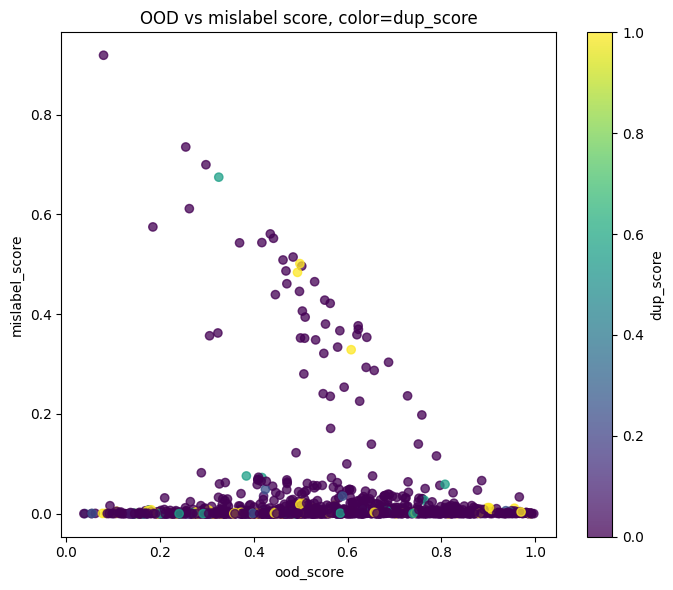

In [13]:
def make_percentile_review_queue(df, score_col, percentiles=(0.90, 0.95, 0.99)):
    rows = []
    for q in percentiles:
        threshold = float(df[score_col].quantile(q))
        count = int((df[score_col] >= threshold).sum())
        rows.append({"score": score_col, "percentile": q, "threshold": threshold, "count_at_or_above": count})
    return pd.DataFrame(rows)

percentile_thresholds = pd.concat([
    make_percentile_review_queue(analysis_df, "ood_score"),
    make_percentile_review_queue(analysis_df, "mislabel_score"),
], ignore_index=True)
display(percentile_thresholds)

ood_top_review = (
    analysis_df[analysis_df["ood_score"] >= analysis_df["ood_score"].quantile(0.95)]
    .sort_values("ood_score", ascending=False)
    .loc[:, [
        "id", "ood_score", "label", "pred_label", "confidence",
        "mean_cos", "centroid_cos", "density_rank", "centroid_rank",
        "mislabel_score", "dup_score", "path",
    ]]
)
mislabel_top_review = (
    analysis_df[analysis_df["mislabel_score"] >= analysis_df["mislabel_score"].quantile(0.95)]
    .sort_values("mislabel_score", ascending=False)
    .loc[:, [
        "id", "mislabel_score", "label", "pred_label", "pred_clean", "pred_dusty",
        "confidence", "disagreement", "ood_score", "dup_score", "path",
    ]]
)

print("OOD top 5 percent review queue")
display(attach_export_path(ood_top_review, "ood"))

print("Mislabel top 5 percent review queue")
display(attach_export_path(mislabel_top_review, "mislabel"))

fig, ax = plt.subplots(figsize=(7, 6))
scatter = ax.scatter(
    analysis_df["ood_score"],
    analysis_df["mislabel_score"],
    c=analysis_df["dup_score"],
    cmap="viridis",
    alpha=0.75,
)
ax.set_title("OOD vs mislabel score, color=dup_score")
ax.set_xlabel("ood_score")
ax.set_ylabel("mislabel_score")
plt.colorbar(scatter, ax=ax, label="dup_score")
plt.tight_layout()
plt.show()

## 8. 현재 해석 메모

- 현재 `dup_score > 0` 후보는 pHash가 주도한다. 이유는 최종 점수가 `max(resnet18_dup_score, phash_dup_score)`이고, source 선택도 pHash 점수가 ResNet 점수 이상이면 pHash로 기록되기 때문이다.
- `nearest_cos_sim >= 0.99`인데 `dup_score`가 낮은 사례는 이상한 것이 아닐 수 있다. CNN 쪽 threshold가 약 0.9967로 높기 때문에 0.99는 CNN dup score 기준으로는 아직 0점 구간이다.
- pHash 기반 `dup_score=0.5` 근처는 보통 pHash distance가 2~3 정도인 경우다. 육안으로 duplicate여도 pHash가 완전 동일하지 않으면 점수가 낮아질 수 있다.
- 육안 검수에서 FP가 거의 없다면 threshold가 보수적일 가능성이 있다. 다음 단계는 `dup_score == 0`이지만 `nearest_cos_sim`이 높거나 `nearest_phash_dist`가 낮은 near-miss 샘플을 추가로 검수하는 것이다.
- OOD와 mislabel은 모든 샘플에 점수가 있으므로 `score > 0` 기준은 검수 기준으로 부적절하다. 0.05 단위 bin과 top percentile 기준으로 먼저 검수 범위를 줄이는 것이 좋다.
- `mislabel_score`는 대부분 0 근처에 몰려 있으므로 상위 5% 또는 1%를 먼저 보는 것이 효율적이다. 반대로 `ood_score`는 전체적으로 퍼져 있으므로 높은 bin부터 단계적으로 확인하는 방식이 더 자연스럽다.

## 9. 점수별 샘플 폴더 출력

아래 셀은 `dup_score`, `ood_score`, `mislabel_score`를 0.05 단위 구간으로 나누고, 각 구간에서 점수가 높은 샘플을 최대 5개씩 별도 폴더로 복사한다. 기존 outlier 이미지가 있으면 그 파일을 우선 사용하고, 없으면 원본 이미지 `path`를 복사한다.


In [14]:
import re
import shutil
from pathlib import Path

SCORE_SAMPLE_OUTPUT_DIR = PROJECT_DIR / "outputs" / "trackB_070102" / "score_bin_sample_exports"
SCORE_SAMPLE_N_PER_BIN = 5
SCORE_SAMPLE_COLUMNS = ["dup_score", "ood_score", "mislabel_score"]

SCORE_SAMPLE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

score_sample_edges = score_bin_edges if "score_bin_edges" in globals() else np.round(np.linspace(0.0, 1.0, 21), 2)
score_sample_labels = [
    f"{score_sample_edges[i]:.2f}-{score_sample_edges[i + 1]:.2f}"
    for i in range(len(score_sample_edges) - 1)
]

outlier_export_lookup = {}
outlier_reason_lookup = {}
if OUTLIER_INDEX_PATH.exists():
    outlier_export_df = pd.read_csv(OUTLIER_INDEX_PATH)
    outlier_export_df["id"] = outlier_export_df["id"].astype(str)
    for row in outlier_export_df.itertuples(index=False):
        key = (str(row.type), str(row.id))
        outlier_export_lookup[key] = str(row.file_path)
        outlier_reason_lookup[key] = str(row.reason)

def safe_token(value, max_len=80):
    text = str(value)
    text = re.sub(r"[^A-Za-z0-9_.-]+", "_", text).strip("_")
    return (text[:max_len] or "na")

def score_token(value):
    return f"{float(value):.4f}".replace("-", "m").replace(".", "p")

def bin_folder_name(rank, bin_label):
    lo, hi = str(bin_label).split("-")
    return f"bin_{rank:02d}_{safe_token(lo)}_{safe_token(hi)}"

def ensure_score_bin(df, score_col):
    bin_col = f"{score_col}_bin"
    if bin_col not in df.columns:
        df[bin_col] = pd.cut(
            df[score_col],
            bins=score_sample_edges,
            labels=score_sample_labels,
            include_lowest=True,
        )
    return bin_col

def preferred_sample_source(row, score_type):
    export_path = outlier_export_lookup.get((score_type, str(row["id"])))
    if export_path and Path(export_path).exists():
        return Path(export_path), outlier_reason_lookup.get((score_type, str(row["id"])), "")
    return Path(row["path"]), "raw image fallback"

def export_score_bin_samples(df, score_col, n_per_bin=5):
    score_type = score_col.replace("_score", "")
    bin_col = ensure_score_bin(df, score_col)
    score_dir = SCORE_SAMPLE_OUTPUT_DIR / score_col
    score_dir.mkdir(parents=True, exist_ok=True)

    exported_rows = []
    missing_rows = []
    ranked_df = df.sort_values(score_col, ascending=False).copy()

    for bin_rank, bin_label in enumerate(reversed(score_sample_labels), start=1):
        bin_df = ranked_df[ranked_df[bin_col].astype(str).eq(str(bin_label))]
        if bin_df.empty:
            continue

        bin_dir = score_dir / bin_folder_name(bin_rank, bin_label)
        bin_dir.mkdir(parents=True, exist_ok=True)

        for local_rank, (_, row) in enumerate(bin_df.head(n_per_bin).iterrows(), start=1):
            src_path, source_reason = preferred_sample_source(row, score_type)
            score_value = float(row[score_col])
            label_part = f"label{safe_token(row.get('label', 'na'))}"
            pred_part = f"pred{safe_token(row.get('pred_label', 'na'))}"
            nearest_id = row.get("effective_nearest_id", row.get("nearest_id", ""))
            nearest_part = f"__near_{safe_token(nearest_id)}" if score_col == "dup_score" and pd.notna(nearest_id) else ""
            suffix = src_path.suffix if src_path.suffix else ".jpg"
            dst_name = (
                f"rank{local_rank:02d}_{score_col.replace('_score', '')}{score_token(score_value)}_"
                f"{safe_token(row['id'])}_{label_part}_{pred_part}{nearest_part}{suffix}"
            )
            dst_path = bin_dir / dst_name

            if src_path.exists():
                shutil.copy2(src_path, dst_path)
                copied_path = dst_path
                missing = False
            else:
                copied_path = pd.NA
                missing = True
                missing_rows.append({
                    "score_col": score_col,
                    "score_bin": str(bin_label),
                    "id": row["id"],
                    "score": score_value,
                    "missing_source_path": str(src_path),
                })

            exported_rows.append({
                "score_col": score_col,
                "score_type": score_type,
                "score_bin": str(bin_label),
                "bin_rank_high_to_low": bin_rank,
                "rank_in_bin": local_rank,
                "id": row["id"],
                "score": score_value,
                "label": row.get("label", pd.NA),
                "pred_label": row.get("pred_label", pd.NA),
                "nearest_id": nearest_id,
                "source_path": str(src_path),
                "copied_path": str(copied_path) if not missing else pd.NA,
                "source_reason": source_reason,
                "missing_source": missing,
            })

    return pd.DataFrame(exported_rows), pd.DataFrame(missing_rows)

score_sample_index_parts = []
score_sample_missing_parts = []
for score_col in SCORE_SAMPLE_COLUMNS:
    if score_col not in analysis_df.columns:
        raise ValueError(f"Missing score column: {score_col}")
    exported_part, missing_part = export_score_bin_samples(
        analysis_df,
        score_col,
        n_per_bin=SCORE_SAMPLE_N_PER_BIN,
    )
    score_sample_index_parts.append(exported_part)
    if not missing_part.empty:
        score_sample_missing_parts.append(missing_part)

score_sample_index = pd.concat(score_sample_index_parts, ignore_index=True)
score_sample_index_path = SCORE_SAMPLE_OUTPUT_DIR / "score_sample_index.csv"
score_sample_index.to_csv(score_sample_index_path, index=False)

score_sample_missing = (
    pd.concat(score_sample_missing_parts, ignore_index=True)
    if score_sample_missing_parts
    else pd.DataFrame(columns=["score_col", "score_bin", "id", "score", "missing_source_path"])
)
if not score_sample_missing.empty:
    score_sample_missing_path = SCORE_SAMPLE_OUTPUT_DIR / "missing_source_files.csv"
    score_sample_missing.to_csv(score_sample_missing_path, index=False)
    print("missing source files:", score_sample_missing_path)
    display(score_sample_missing)

print("saved score sample folders:", SCORE_SAMPLE_OUTPUT_DIR)
print("saved score sample index:", score_sample_index_path)
display(
    score_sample_index
    .groupby(["score_col", "score_bin"], observed=False)
    .agg(exported=("copied_path", "count"), missing=("missing_source", "sum"))
    .reset_index()
    .query("exported > 0 or missing > 0")
)


saved score sample folders: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/outputs/trackB_070102/score_bin_sample_exports
saved score sample index: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/outputs/trackB_070102/score_bin_sample_exports/score_sample_index.csv


,score_col,score_bin,exported,missing
0,dup_score,0.00-0.05,5,0
1,dup_score,0.05-0.10,5,0
2,dup_score,0.20-0.25,5,0
3,dup_score,0.55-0.60,5,0
4,dup_score,0.95-1.00,5,0
5,mislabel_score,0.00-0.05,5,0
6,mislabel_score,0.05-0.10,5,0
7,mislabel_score,0.10-0.15,4,0
8,mislabel_score,0.15-0.20,2,0
9,mislabel_score,0.20-0.25,4,0


## 10. Mislabel 판단력 추가 진단 플롯

`mislabel_score`가 실제로 어떤 신호를 반영하는지 보기 위해 OOD 축과 함께 네 가지 관계를 본다. 현재 detail CSV에는 k개 이웃 전체 라벨이 아니라 `nearest_label`만 있으므로, `knn_label_disagreement`는 1-NN 기준으로 현재 라벨과 가장 가까운 샘플 라벨이 다른지로 계산한다.


max(raw_model_disagreement - saved disagreement): 8.265487850015948e-08
1-NN label coverage: 1366 / 1366
1-NN label disagreement count: 123


,count,mean,std,min,50%,90%,95%,99%,max
raw_model_disagreement,1366.0,0.069855,0.203537,1.951318e-11,0.001772,0.170564,0.599011,0.991458,0.999975
confidence,1366.0,0.937729,0.162397,4.230618e-03,0.996554,0.999979,0.999997,1.000000,1.000000
knn_label_disagreement,1366.0,0.090044,0.286350,0.000000e+00,0.000000,0.000000,1.000000,1.000000,1.000000
final_mislabel_score,1366.0,0.020653,0.083063,1.486201e-11,0.000759,0.026554,0.062353,0.490150,0.919247
ood_score,1366.0,0.499634,0.211868,3.748170e-02,0.480234,0.814422,0.884370,0.976142,0.997218


,spearman_corr_with_ood_score
raw_model_disagreement,0.450600
confidence,-0.464667
knn_label_disagreement,0.176143
final_mislabel_score,0.286223


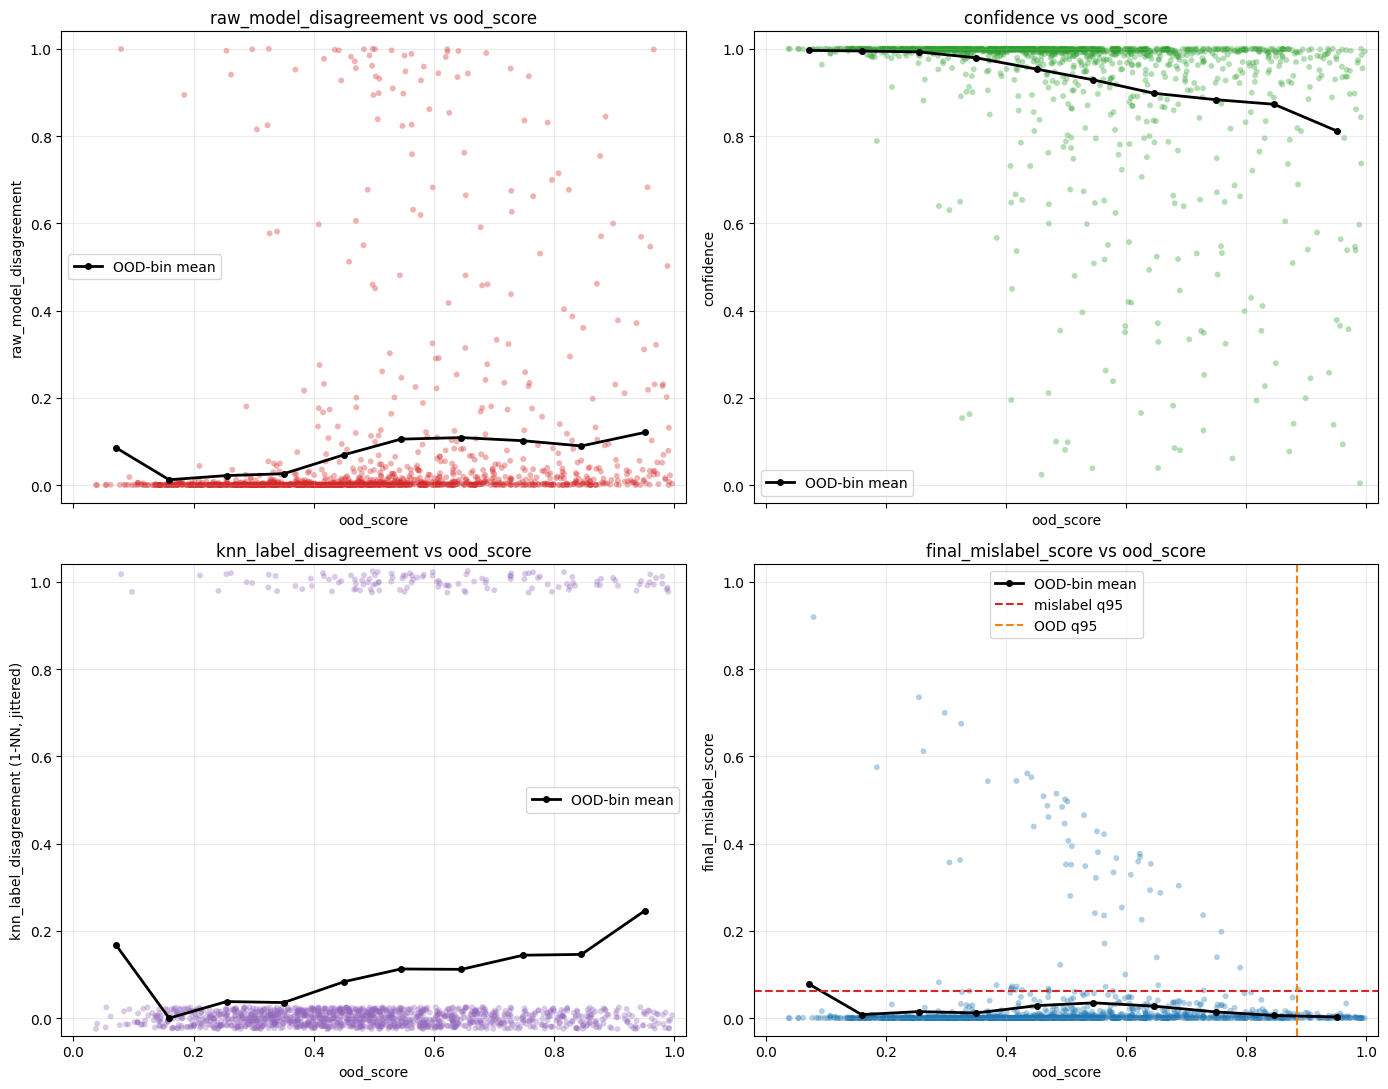

saved diagnostic plot: /home/thkim0/github/AIFFEL_quest_rs/MainQuest/Quest02/outputs/trackB_070102/mislabel_diagnostic_vs_ood.png


In [15]:
diagnostic_required_columns = {
    "label", "nearest_label", "pred_clean", "pred_dusty",
    "confidence", "ood_score", "mislabel_score",
}
missing_diagnostic_columns = sorted(diagnostic_required_columns - set(analysis_df.columns))
if missing_diagnostic_columns:
    raise ValueError(f"Missing diagnostic columns: {missing_diagnostic_columns}")

label_numeric = pd.to_numeric(analysis_df["label"], errors="coerce")
nearest_label_numeric = pd.to_numeric(analysis_df["nearest_label"], errors="coerce")
pred_clean_numeric = pd.to_numeric(analysis_df["pred_clean"], errors="coerce")
pred_dusty_numeric = pd.to_numeric(analysis_df["pred_dusty"], errors="coerce")

analysis_df["raw_model_disagreement"] = np.where(
    label_numeric.eq(1),
    pred_clean_numeric,
    pred_dusty_numeric,
)
analysis_df["knn_label_disagreement"] = np.where(
    nearest_label_numeric.notna(),
    label_numeric.ne(nearest_label_numeric).astype(float),
    np.nan,
)
analysis_df["final_mislabel_score"] = pd.to_numeric(analysis_df["mislabel_score"], errors="coerce")

for col in ["raw_model_disagreement", "confidence", "ood_score", "knn_label_disagreement", "final_mislabel_score"]:
    analysis_df[col] = pd.to_numeric(analysis_df[col], errors="coerce")

if "disagreement" in analysis_df.columns:
    disagreement_max_diff = (
        analysis_df["raw_model_disagreement"]
        .sub(pd.to_numeric(analysis_df["disagreement"], errors="coerce"))
        .abs()
        .max()
    )
    print("max(raw_model_disagreement - saved disagreement):", float(disagreement_max_diff))

knn_coverage = int(analysis_df["knn_label_disagreement"].notna().sum())
knn_disagreement_count = int(analysis_df["knn_label_disagreement"].fillna(0).sum())
print(f"1-NN label coverage: {knn_coverage} / {len(analysis_df)}")
print(f"1-NN label disagreement count: {knn_disagreement_count}")

diagnostic_summary = analysis_df[[
    "raw_model_disagreement", "confidence", "knn_label_disagreement",
    "final_mislabel_score", "ood_score",
]].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).T
display(diagnostic_summary)

diagnostic_spearman = (
    analysis_df[[
        "raw_model_disagreement", "confidence", "knn_label_disagreement",
        "final_mislabel_score", "ood_score",
    ]]
    .corr(method="spearman")
    .loc[["raw_model_disagreement", "confidence", "knn_label_disagreement", "final_mislabel_score"], ["ood_score"]]
    .rename(columns={"ood_score": "spearman_corr_with_ood_score"})
)
display(diagnostic_spearman)

rng = np.random.default_rng(42)

def add_binned_mean_line(ax, df, x_col, y_col, bins=10):
    plot_df = df[[x_col, y_col]].dropna().copy()
    if plot_df.empty:
        return
    x_bins = pd.cut(plot_df[x_col], bins=np.linspace(0, 1, bins + 1), include_lowest=True)
    line_df = (
        plot_df.groupby(x_bins, observed=False)
        .agg(x_mean=(x_col, "mean"), y_mean=(y_col, "mean"), count=(y_col, "size"))
        .dropna(subset=["x_mean", "y_mean"])
        .reset_index(drop=True)
    )
    if not line_df.empty:
        ax.plot(
            line_df["x_mean"],
            line_df["y_mean"],
            color="black",
            linewidth=2,
            marker="o",
            markersize=4,
            label="OOD-bin mean",
        )
        ax.legend(loc="best")

def plot_vs_ood(ax, df, y_col, title, y_label=None, jitter_y=0.0, color="tab:blue"):
    plot_df = df[["ood_score", y_col]].dropna().copy()
    x = plot_df["ood_score"].to_numpy(dtype=float)
    y = plot_df[y_col].to_numpy(dtype=float)
    y_plot = y
    if jitter_y > 0:
        y_plot = np.clip(y + rng.uniform(-jitter_y, jitter_y, size=len(y)), -0.04, 1.04)

    ax.scatter(x, y_plot, s=18, alpha=0.35, color=color, edgecolors="none")
    add_binned_mean_line(ax, plot_df, "ood_score", y_col)
    ax.set_title(title)
    ax.set_xlabel("ood_score")
    ax.set_ylabel(y_label or y_col)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.04, 1.04)
    ax.grid(alpha=0.25)

fig, axes = plt.subplots(2, 2, figsize=(14, 11), sharex=True, sharey=False)
plot_vs_ood(
    axes[0, 0],
    analysis_df,
    "raw_model_disagreement",
    "raw_model_disagreement vs ood_score",
    "raw_model_disagreement",
    color="tab:red",
)
plot_vs_ood(
    axes[0, 1],
    analysis_df,
    "confidence",
    "confidence vs ood_score",
    "confidence",
    color="tab:green",
)
plot_vs_ood(
    axes[1, 0],
    analysis_df,
    "knn_label_disagreement",
    "knn_label_disagreement vs ood_score",
    "knn_label_disagreement (1-NN, jittered)",
    jitter_y=0.025,
    color="tab:purple",
)
plot_vs_ood(
    axes[1, 1],
    analysis_df,
    "final_mislabel_score",
    "final_mislabel_score vs ood_score",
    "final_mislabel_score",
    color="tab:blue",
)

mislabel_q95 = float(analysis_df["final_mislabel_score"].quantile(0.95))
ood_q95 = float(analysis_df["ood_score"].quantile(0.95))
axes[1, 1].axhline(mislabel_q95, color="tab:red", linestyle="--", linewidth=1.5, label="mislabel q95")
axes[1, 1].axvline(ood_q95, color="tab:orange", linestyle="--", linewidth=1.5, label="OOD q95")
axes[1, 1].legend(loc="best")

plt.tight_layout()
MISLABEL_DIAGNOSTIC_PLOT_PATH = PROJECT_DIR / "outputs" / "trackB_070102" / "mislabel_diagnostic_vs_ood.png"
fig.savefig(MISLABEL_DIAGNOSTIC_PLOT_PATH, dpi=160, bbox_inches="tight")
plt.show()
print("saved diagnostic plot:", MISLABEL_DIAGNOSTIC_PLOT_PATH)
